# Project: Digit Recognition App from Scratch
Welcome to the Digit Recognition tutorial! In this project, we are going to teach our computer how to "read" handwritten numbers (0-9). 

To do this, we will use the famous **MNIST dataset**, which contains 60,000 tiny images of handwritten digits. 

### Section 1: Loading and Visualizing the Data
Before we can build an Artificial Intelligence, we need to understand our data. Let's import our standard data science and deep learning libraries. We will use PyTorch (`torchvision`) simply to download the dataset easily.

In [15]:
# Import deep learning frameworks
import torch
import torchvision
from torchvision import transforms

# Import visualization and math libraries
import matplotlib.pyplot as plt
import numpy as np

print("All libraries successfully imported!")

All libraries successfully imported!


### Downloading the MNIST Dataset
An image is just a grid of pixels. In the MNIST dataset, every image is exactly **28 pixels wide and 28 pixels tall**. Since they are black and white (grayscale), they only have 1 color channel. 

Let's download the dataset and convert those images into numerical matrices (tensors) that our future math functions can understand.

In [ ]:
# We use transforms.ToTensor() to convert raw images into numerical matrices
transform = transforms.ToTensor()

# Download the training data into a local folder named '/data'
train_dataset = torchvision.datasets.MNIST(root='./data', 
                                           train=True, 
                                           download=True, 
                                           transform=transform)

print(f"Successfully loaded {len(train_dataset)} training images!")

### Visualizing the Digits
It is hard to understand data when it is just raw numbers in a matrix. Let's use **Matplotlib** to print out the first 10 images in our dataset so we can actually see what our neural network will be looking at!

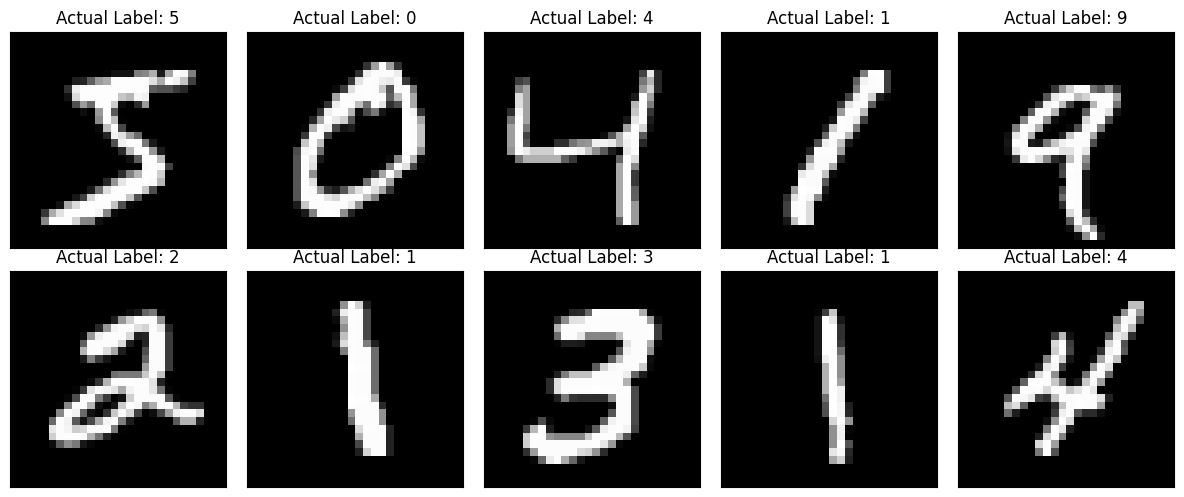

In [3]:
# Create a blank canvas (figure) for our images
fig = plt.figure(figsize=(12, 5))

# Loop through the first 10 images in our dataset
for i in range(10):
    # The dataset gives us a tuple containing the image matrix and its actual label
    image, label = train_dataset[i]
    
    # Add a subplot (2 rows, 5 columns, current index)
    ax = fig.add_subplot(2, 5, i+1, xticks=[], yticks=[])
    
    # PyTorch matrices are formatted as (Channels, Height, Width) -> (1, 28, 28)
    # Matplotlib needs just (Height, Width) for grayscale, so we use .squeeze() to drop the 1
    ax.imshow(image.squeeze(), cmap='gray')
    
    # Set the title of the image to its actual number
    ax.set_title(f"Actual Label: {label}")

plt.tight_layout()
plt.show()

### Section 2: Building a Neural Network from Scratch (NumPy)
Before we use modern tools like PyTorch, let's build the math ourselves using pure NumPy. This will demystify how AI actually "learns."

First, we need to prepare our image data. A neural network doesn't look at a 2D grid; it wants a single long line of numbers. So, we will **flatten** our 28x28 pixel images into a 1D array of 784 pixels. We will also normalize the pixel values to be between 0 and 1.

In [4]:
# Convert PyTorch tensors into standard NumPy arrays for our custom math
# We reshape (60000, 28, 28) into (60000, 784)
X_train = train_dataset.data.numpy().reshape(-1, 28*28) / 255.0

# Get the labels (0 through 9)
Y_train_raw = train_dataset.targets.numpy()

# One-Hot Encoding: Convert a label like '3' into an array like [0,0,0,1,0,0,0,0,0,0]
def one_hot_encode(Y, num_classes=10):
    one_hot = np.zeros((Y.size, num_classes))
    one_hot[np.arange(Y.size), Y] = 1
    return one_hot

Y_train = one_hot_encode(Y_train_raw)

print(f"Flattened Image Shape: {X_train.shape}")
print(f"One-Hot Label Shape: {Y_train.shape}")

Flattened Image Shape: (60000, 784)
One-Hot Label Shape: (60000, 10)


### Step 1: Initializing the Brain
Our network will have three layers:
1. **Input Layer:** 784 nodes (one for each pixel).
2. **Hidden Layer:** 128 nodes (the network's "brain" where it finds patterns).
3. **Output Layer:** 10 nodes (the final probabilities for digits 0-9).

We start by giving the network random "weights" and zero "biases."

In [5]:
# Set a random seed so get the same results every time
np.random.seed(42)

# Initialize Weights and Biases
# Weights are randomly chosen, Biases start at 0
W1 = np.random.randn(784, 128) * 0.01  # Weights from Input -> Hidden
b1 = np.zeros((1, 128))                # Biases for Hidden Layer

W2 = np.random.randn(128, 10) * 0.01   # Weights from Hidden -> Output
b2 = np.zeros((1, 10))                 # Biases for Output Layer

print("Weights and Biases Initialized!")

Weights and Biases Initialized!


### Step 2: Forward Propagation (Making a Guess)
To make a guess, the data flows forward. We multiply the pixels by the weights and add the biases. 

We also pass the results through **Activation Functions**:
* **ReLU (Rectified Linear Unit):** Turns negative numbers to 0. This helps the network learn complex patterns.
* **Softmax:** Turns the final 10 numbers into percentages (probabilities) that add up to 100%.

In [6]:
# Activation Functions
def relu(Z):
    return np.maximum(0, Z)

def softmax(Z):
    expZ = np.exp(Z - np.max(Z, axis=1, keepdims=True)) # Stabilized for math errors
    return expZ / np.sum(expZ, axis=1, keepdims=True)

# The Forward Pass
def forward_propagation(X, W1, b1, W2, b2):
    # Layer 1
    Z1 = np.dot(X, W1) + b1
    A1 = relu(Z1)
    
    # Layer 2
    Z2 = np.dot(A1, W2) + b2
    A2 = softmax(Z2)
    
    return Z1, A1, Z2, A2

### Step 3: Backpropagation (Learning from Mistakes)
Once the network makes a guess, we compare it to the correct answer. We calculate the "error" (loss) and use calculus (the chain rule) to work backward and adjust the weights so it makes a better guess next time.

In [7]:
# Derivative of ReLU for our calculus chain rule
def relu_derivative(Z):
    return Z > 0

# The Backward Pass
def backward_propagation(X, Y, Z1, A1, A2, W2):
    m = X.shape[0] # Number of images
    
    # Calculate Output Error (Prediction - Actual)
    dZ2 = A2 - Y
    dW2 = (1 / m) * np.dot(A1.T, dZ2)
    db2 = (1 / m) * np.sum(dZ2, axis=0, keepdims=True)
    
    # Calculate Hidden Layer Error
    dZ1 = np.dot(dZ2, W2.T) * relu_derivative(Z1)
    dW1 = (1 / m) * np.dot(X.T, dZ1)
    db1 = (1 / m) * np.sum(dZ1, axis=0, keepdims=True)
    
    return dW1, db1, dW2, db2

### Step 4: The Training Loop
Now we put it all together! We will feed the dataset into our network, let it guess, calculate the error, and update the weights. We will do this 100 times (epochs) and watch the accuracy go up!

In [8]:
learning_rate = 0.5
epochs = 100
m = X_train.shape[0]

# Standard metric to check how well we are doing
def get_accuracy(predictions, Y_true):
    return np.mean(predictions == Y_true) * 100

for i in range(epochs):
    # 1. Guess
    Z1, A1, Z2, A2 = forward_propagation(X_train, W1, b1, W2, b2)
    
    # 2. Find Errors
    dW1, db1, dW2, db2 = backward_propagation(X_train, Y_train, Z1, A1, A2, W2)
    
    # 3. Update Weights
    W1 = W1 - learning_rate * dW1
    b1 = b1 - learning_rate * db1
    W2 = W2 - learning_rate * dW2
    b2 = b2 - learning_rate * db2
    
    # Print progress every 20 epochs
    if i % 20 == 0:
        predictions = np.argmax(A2, axis=1)
        accuracy = get_accuracy(predictions, Y_train_raw)
        print(f"Epoch {i}: Accuracy = {accuracy:.2f}%")

print("Training Complete! The network has learned how to read.")

Epoch 0: Accuracy = 12.48%
Epoch 20: Accuracy = 77.25%
Epoch 40: Accuracy = 84.56%
Epoch 60: Accuracy = 86.70%
Epoch 80: Accuracy = 89.53%
Training Complete! The network has learned how to read.


### Section 3: The Modern Way (Transition to PyTorch)
Writing backpropagation by hand is great for learning, but it is too slow for massive real-world datasets. Modern AI Engineers use frameworks like **PyTorch**. 

PyTorch handles the calculus automatically using a feature called `Autograd`. Let's rebuild our exact same Multi-Layer Perceptron (MLP) using PyTorch!

First, we need to load our data in **Batches**. Instead of feeding all 60,000 images at once, we feed them 64 at a time to save computer memory.

In [9]:
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader

# Create a DataLoader to automatically batch and shuffle our images
batch_size = 64
train_loader = DataLoader(dataset=train_dataset, batch_size=batch_size, shuffle=True)

print(f"Data ready! We have {len(train_loader)} batches of {batch_size} images.")

Data ready! We have 938 batches of 64 images.


### Building the PyTorch Model
In PyTorch, we build networks using Classes. Notice how we don't have to initialize random math matrices anymore; we just tell PyTorch we want a `Linear` layer with 784 inputs and 128 outputs.

In [10]:
class PyTorchMLP(nn.Module):
    def __init__(self):
        super(PyTorchMLP, self).__init__()
        # This completely replaces our W1, b1, W2, b2 math!
        self.layer1 = nn.Linear(28 * 28, 128)
        self.relu = nn.ReLU()
        self.layer2 = nn.Linear(128, 10)
        
    def forward(self, x):
        # Flatten the 2D image into a 1D line of pixels
        x = x.view(-1, 28 * 28)
        
        # Pass data through the layers
        x = self.layer1(x)
        x = self.relu(x)
        x = self.layer2(x) 
        # Note: We don't need to write a Softmax function here. PyTorch's 
        # loss function handles the Softmax math automatically for us!
        return x

# Create an instance of our model
model = PyTorchMLP()
print(model)

PyTorchMLP(
  (layer1): Linear(in_features=784, out_features=128, bias=True)
  (relu): ReLU()
  (layer2): Linear(in_features=128, out_features=10, bias=True)
)


### Training the PyTorch Model
Now we train it. Look at how clean the training loop is. The `loss.backward()` command handles all the complex calculus and derivatives we wrote from scratch in the last section!

In [11]:
# CrossEntropyLoss automatically applies Softmax and calculates the error
criterion = nn.CrossEntropyLoss()

# Stochastic Gradient Descent (SGD) will update our weights
optimizer = optim.SGD(model.parameters(), lr=0.1)

epochs = 3 # We only need a few epochs because PyTorch is highly optimized

print("Starting PyTorch Training...")
for epoch in range(epochs):
    running_loss = 0.0
    
    # Loop through our batches
    for images, labels in train_loader:
        
        # 1. Clear old gradients
        optimizer.zero_grad()
        
        # 2. Forward Pass (Make a guess)
        outputs = model(images)
        
        # 3. Calculate Loss (How wrong were we?)
        loss = criterion(outputs, labels)
        
        # 4. Backward Pass (Calculus magic!)
        loss.backward()
        
        # 5. Update Weights
        optimizer.step()
        
        running_loss += loss.item()
        
    print(f"Epoch {epoch+1} Complete | Average Loss: {running_loss/len(train_loader):.4f}")

print("PyTorch Training Complete!")

Starting PyTorch Training...
Epoch 1 Complete | Average Loss: 0.4431
Epoch 2 Complete | Average Loss: 0.2275
Epoch 3 Complete | Average Loss: 0.1707
PyTorch Training Complete!


### What's Next? Convolutional Neural Networks (CNNs)
Our MLP model gets around 95% accuracy. But what if the number is shifted to the left or right of the image? An MLP gets confused because it looks at exact pixel locations.

To get 99%+ accuracy, modern AI uses **Convolutional Neural Networks (CNNs)**. CNNs use "filters" that slide across the image to detect edges and shapes, no matter where they are located. 

*Here is what a CNN architecture looks like in PyTorch. As a challenge, try replacing the MLP model above with this CNN and see how your accuracy improves!*

In [12]:
# A simple CNN Architecture for the students to explore later
class SimpleCNN(nn.Module):
    def __init__(self):
        super(SimpleCNN, self).__init__()
        # Convolutional Layer (Finds edges and patterns)
        self.conv1 = nn.Conv2d(in_channels=1, out_channels=16, kernel_size=3, stride=1, padding=1)
        self.relu = nn.ReLU()
        # Max Pooling (Shrinks the image to keep the most important features)
        self.pool = nn.MaxPool2d(kernel_size=2, stride=2)
        
        # Fully Connected Layer (Makes the final guess)
        self.fc = nn.Linear(16 * 14 * 14, 10)
        
    def forward(self, x):
        x = self.conv1(x)
        x = self.relu(x)
        x = self.pool(x)
        x = x.view(x.size(0), -1) # Flatten
        x = self.fc(x)
        return x

print("CNN Architecture defined! Ready for advanced training.")

CNN Architecture defined! Ready for advanced training.


### Training the CNN (Proving the Power of Convolutions)
Let's prove that the CNN is a more powerful architecture for images. We will train our `SimpleCNN` for **3 epochs** to watch it learn. 

Notice that we will use a more advanced optimizer called **Adam**, which is the industry standard for Deep Learning models today. It helps CNNs learn complex patterns much faster.

In [14]:
# Initialize the CNN model
cnn_model = SimpleCNN()

# Use the Adam optimizer, which is highly efficient for CNNs
cnn_optimizer = optim.Adam(cnn_model.parameters(), lr=0.001)

cnn_epochs = 3
print(f"Starting CNN Training ({cnn_epochs} Epochs)...")

for epoch in range(cnn_epochs):
    running_loss = 0.0
    
    # Loop through all batches in the dataset
    for images, labels in train_loader:
        # 1. Clear old gradients
        cnn_optimizer.zero_grad()
        
        # 2. Forward Pass
        outputs = cnn_model(images)
        
        # 3. Calculate Loss
        loss = criterion(outputs, labels)
        
        # 4. Backward Pass
        loss.backward()
        
        # 5. Update Weights
        cnn_optimizer.step()
        
        running_loss += loss.item()
        
    # Print the average loss for this epoch
    print(f"Epoch {epoch+1} Complete | Average Loss: {running_loss/len(train_loader):.4f}")

print("CNN Training Complete! Notice how the loss continues to drop.")

Starting CNN Training (3 Epochs)...
Epoch 1 Complete | Average Loss: 0.3036
Epoch 2 Complete | Average Loss: 0.1065
Epoch 3 Complete | Average Loss: 0.0775
CNN Training Complete! Notice how the loss continues to drop.
